In [1]:

import matplotlib.pyplot as plt

from scipy.optimize import curve_fit

#Import all needed libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_context("talk", font_scale=1.5)

In [2]:
save_path = '../../../data/supp_figures/supp_fig_1_exponential/'
df_his = pd.read_csv(save_path + 'df_tau_raw.csv', index_col=0)

C:\Users\tiffany.ona\AppData\Local\Temp\ipykernel_44880\2644426342.py:14: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(exp_decay, np.arange(len(dat[animal][1:])), dat[animal][1:],maxfev=6000)


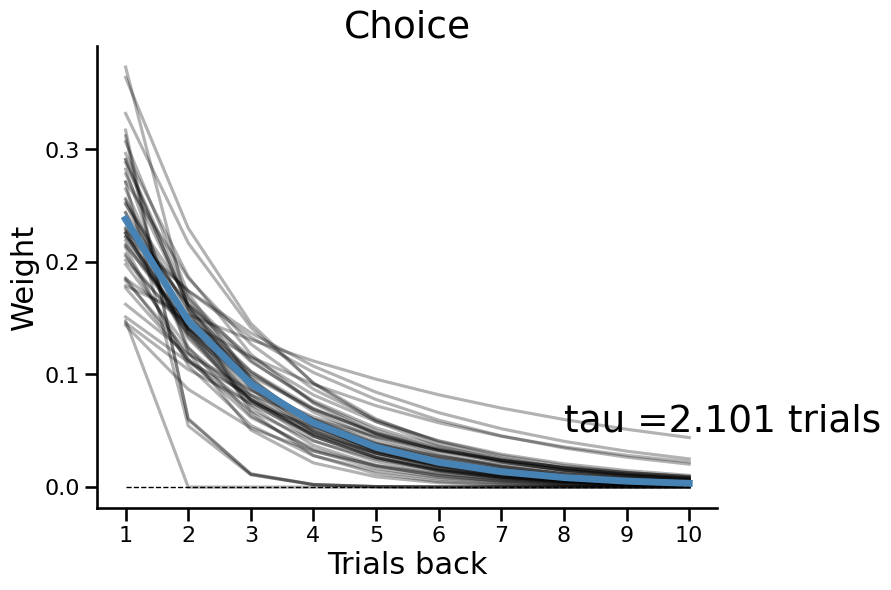

In [3]:
def exp_decay(t, N0, tau):
    return N0 * np.exp(-t / tau)

f, ax = plt.subplots(nrows=1, ncols=1, figsize=(8, 6))
plt.setp(ax.get_xticklabels(), fontsize=16)
plt.setp(ax.get_yticklabels(), fontsize=16)

for ind,dat in zip([0],[df_his]):
    acc_tau = []
    acc_N0 = []
    xs = np.arange(dat.shape[0])
    for animal in df_his.columns:
        try:
            popt, pcov = curve_fit(exp_decay, np.arange(len(dat[animal][1:])), dat[animal][1:],maxfev=6000)
            N0, tau = popt
            ax.plot(xs+1,N0 * np.exp(-xs /tau), color='black',alpha=0.3)
            ax.set_title('Choice')

            acc_tau+=[tau]
            acc_N0+=[N0]
        except:
            print('No tau')
            acc_tau+=[2.2]
            acc_N0+=[0]

    ax.plot(xs+1, np.mean(acc_N0) * np.exp(-xs / np.median(acc_tau)),color='steelblue',linewidth=5)
    ax.text(x=8,y=0.05,s='tau ='+str(np.round(np.median(acc_tau),3))+' trials')
    ax.hlines(xmin=1,xmax=10,y=0,linestyles='dashed', color='black',linewidth=1)
    ax.set_xticks([1,2,3,4,5,6,7,8,9,10])
    ax.set_xlabel('Trials back', fontsize=22)
    ax.set_ylabel('Weight', fontsize=22)
    ax.set_facecolor('white')
    sns.despine()

# plt.savefig(save_path+'/taus.png', dpi =300, bbox_inches='tight')
# plt.tight_layout()

C:\Users\tiffany.ona\AppData\Local\Temp\ipykernel_44880\3244319357.py:12: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(exp_decay, np.arange(len(df_his[animal][1:])), df_his[animal][1:],maxfev = 6000)


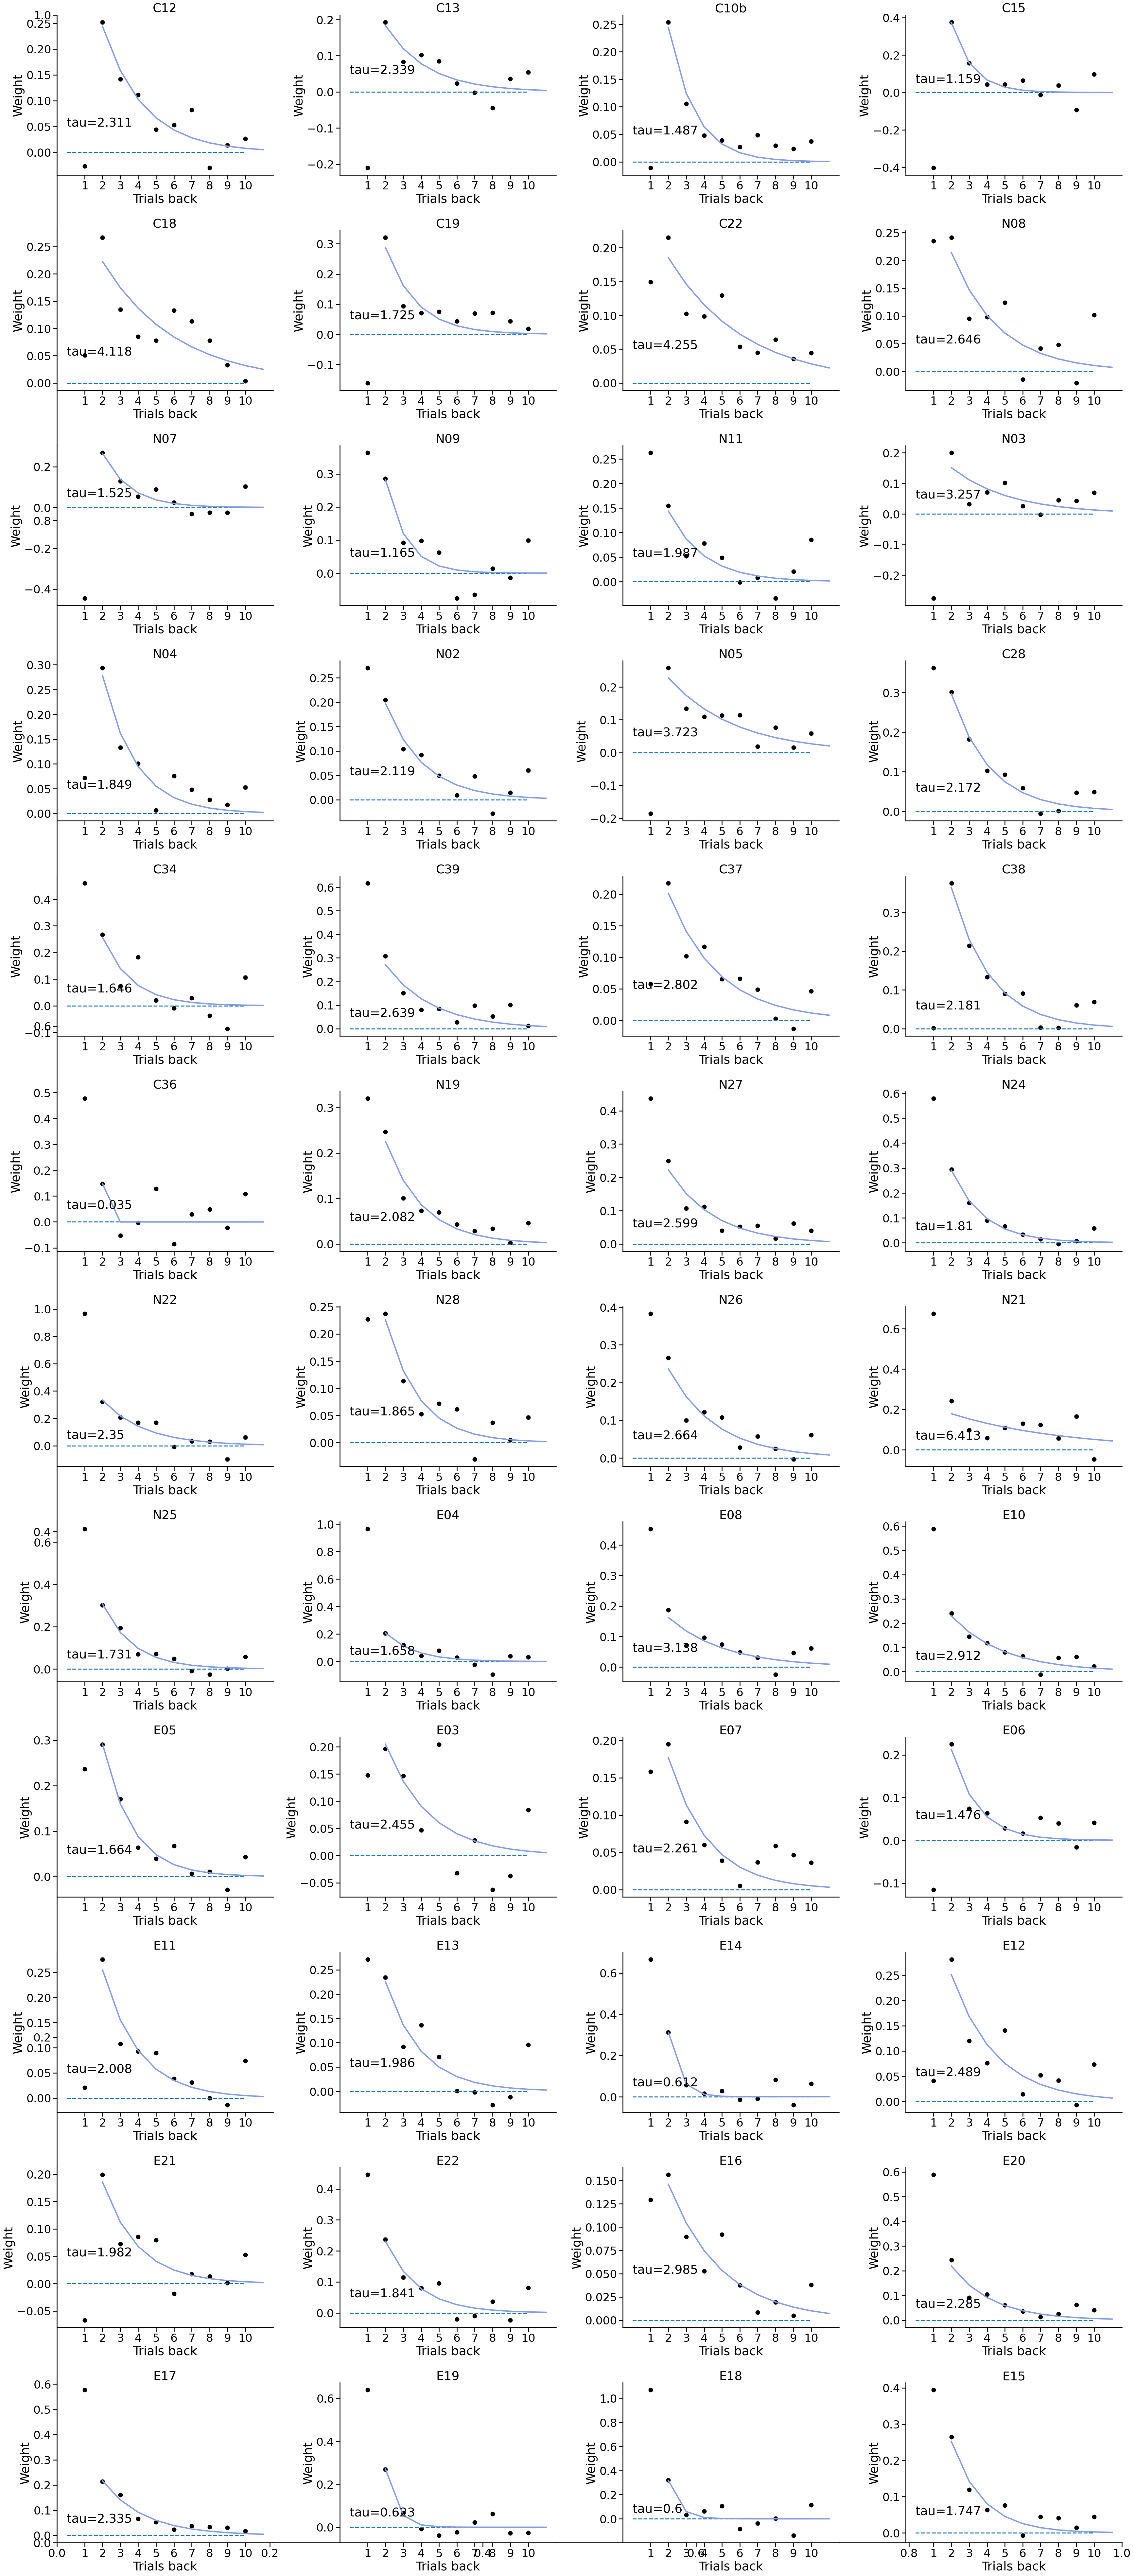

In [4]:
def exp_decay(t, N0, tau):
    return N0 * np.exp(-t / tau)

f = plt.subplots(figsize=(36,80))

index=0
for animal in df_his.columns:
    axes = plt.subplot(12,4,index+1)
    index+=1
    for ind,dat,light,main in zip([0],[df_his],["#000000"],["#859EE1"]):

        popt, pcov = curve_fit(exp_decay, np.arange(len(df_his[animal][1:])), df_his[animal][1:],maxfev = 6000)
        N0, tau = popt
        xs = np.arange(len(df_his[animal]))
        axes.plot(dat[animal].index+1, df_his[animal],'o', color=light)

        axes.hlines(xmin=0,xmax=len(df_his[animal]),y=0,linestyles='dashed')

        axes.plot(xs+2, np.mean(N0) * np.exp(-xs / tau),label='Fit (tau='+str(np.round(tau,3))+')' , color=main, linewidth=3)
        axes.set_title(animal)
        if ind == 0:
            axes.text(x=0,y=0.05,s='tau='+str(np.round(np.median(tau),3)))

    axes.set_xlabel('Trials back')
    axes.set_ylabel('Weight')
    axes.set_xticks([1,2,3,4,5,6,7,8,9,10])
    axes.set_facecolor('white')
    sns.despine()
plt.tight_layout()